<a href="https://colab.research.google.com/github/HishitaGupta/Colab-Notebooks/blob/main/GRU_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Next Word Predictor - smart compose
- There is need to convert corpus of data into Supervised ML Problem with input data and output data.

In [1]:
 text ="""The weather is beautiful today.
 I love walking in the park.
 Birds are singing and the sky is clear.
 Sometimes it rains heavily in the evening.
 I enjoy reading books on quiet rainy nights.
 Nature always brings peace and happiness to the mind."""

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

In [3]:
# Initiate the Tokenizer

tokenizer = Tokenizer()

In [4]:
tokenizer.fit_on_texts([text])

In [5]:
len(tokenizer.word_index)

35

In [6]:
for sentence in text.split('\n'):
  print(sentence)

The weather is beautiful today.
I love walking in the park.
Birds are singing and the sky is clear.
Sometimes it rains heavily in the evening.
I enjoy reading books on quiet rainy nights.
Nature always brings peace and happiness to the mind.


In [7]:
for sentence in text.split('\n'):
  print(tokenizer.texts_to_sequences([sentence]))

[[1, 6, 2, 7, 8]]
[[3, 9, 10, 4, 1, 11]]
[[12, 13, 14, 5, 1, 15, 2, 16]]
[[17, 18, 19, 20, 4, 1, 21]]
[[3, 22, 23, 24, 25, 26, 27, 28]]
[[29, 30, 31, 32, 5, 33, 34, 1, 35]]


In [8]:
# Create Input and Output Sequences

input_sequences =[];

for sentence in text.split('\n'):
  tokenized_sentence = tokenizer.texts_to_sequences([sentence])[0]

  for i in range(1, len(tokenized_sentence)):
    input_sequences.append(tokenized_sentence[:i+1])



In [9]:
input_sequences

[[1, 6],
 [1, 6, 2],
 [1, 6, 2, 7],
 [1, 6, 2, 7, 8],
 [3, 9],
 [3, 9, 10],
 [3, 9, 10, 4],
 [3, 9, 10, 4, 1],
 [3, 9, 10, 4, 1, 11],
 [12, 13],
 [12, 13, 14],
 [12, 13, 14, 5],
 [12, 13, 14, 5, 1],
 [12, 13, 14, 5, 1, 15],
 [12, 13, 14, 5, 1, 15, 2],
 [12, 13, 14, 5, 1, 15, 2, 16],
 [17, 18],
 [17, 18, 19],
 [17, 18, 19, 20],
 [17, 18, 19, 20, 4],
 [17, 18, 19, 20, 4, 1],
 [17, 18, 19, 20, 4, 1, 21],
 [3, 22],
 [3, 22, 23],
 [3, 22, 23, 24],
 [3, 22, 23, 24, 25],
 [3, 22, 23, 24, 25, 26],
 [3, 22, 23, 24, 25, 26, 27],
 [3, 22, 23, 24, 25, 26, 27, 28],
 [29, 30],
 [29, 30, 31],
 [29, 30, 31, 32],
 [29, 30, 31, 32, 5],
 [29, 30, 31, 32, 5, 33],
 [29, 30, 31, 32, 5, 33, 34],
 [29, 30, 31, 32, 5, 33, 34, 1],
 [29, 30, 31, 32, 5, 33, 34, 1, 35]]

In [10]:
# Can't pass this similar data to neural network - need to convert them to similar dimesnions. Therefore, zero padding , adding zeroes at front and back

[len(c) for c in input_sequences]


[2,
 3,
 4,
 5,
 2,
 3,
 4,
 5,
 6,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 2,
 3,
 4,
 5,
 6,
 7,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9]

In [11]:
# Max Len : 9

max_len = 9

In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_input_sequences =pad_sequences(input_sequences, maxlen = max_len,padding='pre')

In [13]:
padded_input_sequences

array([[ 0,  0,  0,  0,  0,  0,  0,  1,  6],
       [ 0,  0,  0,  0,  0,  0,  1,  6,  2],
       [ 0,  0,  0,  0,  0,  1,  6,  2,  7],
       [ 0,  0,  0,  0,  1,  6,  2,  7,  8],
       [ 0,  0,  0,  0,  0,  0,  0,  3,  9],
       [ 0,  0,  0,  0,  0,  0,  3,  9, 10],
       [ 0,  0,  0,  0,  0,  3,  9, 10,  4],
       [ 0,  0,  0,  0,  3,  9, 10,  4,  1],
       [ 0,  0,  0,  3,  9, 10,  4,  1, 11],
       [ 0,  0,  0,  0,  0,  0,  0, 12, 13],
       [ 0,  0,  0,  0,  0,  0, 12, 13, 14],
       [ 0,  0,  0,  0,  0, 12, 13, 14,  5],
       [ 0,  0,  0,  0, 12, 13, 14,  5,  1],
       [ 0,  0,  0, 12, 13, 14,  5,  1, 15],
       [ 0,  0, 12, 13, 14,  5,  1, 15,  2],
       [ 0, 12, 13, 14,  5,  1, 15,  2, 16],
       [ 0,  0,  0,  0,  0,  0,  0, 17, 18],
       [ 0,  0,  0,  0,  0,  0, 17, 18, 19],
       [ 0,  0,  0,  0,  0, 17, 18, 19, 20],
       [ 0,  0,  0,  0, 17, 18, 19, 20,  4],
       [ 0,  0,  0, 17, 18, 19, 20,  4,  1],
       [ 0,  0, 17, 18, 19, 20,  4,  1, 21],
       [ 0

In [14]:
# X = whole of padded sequences minus the last item of each sequence
# y = the last item of each sequence

X = padded_input_sequences[:,:-1]
y = padded_input_sequences[:,-1]


In [15]:
X

array([[ 0,  0,  0,  0,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  1,  6],
       [ 0,  0,  0,  0,  0,  1,  6,  2],
       [ 0,  0,  0,  0,  1,  6,  2,  7],
       [ 0,  0,  0,  0,  0,  0,  0,  3],
       [ 0,  0,  0,  0,  0,  0,  3,  9],
       [ 0,  0,  0,  0,  0,  3,  9, 10],
       [ 0,  0,  0,  0,  3,  9, 10,  4],
       [ 0,  0,  0,  3,  9, 10,  4,  1],
       [ 0,  0,  0,  0,  0,  0,  0, 12],
       [ 0,  0,  0,  0,  0,  0, 12, 13],
       [ 0,  0,  0,  0,  0, 12, 13, 14],
       [ 0,  0,  0,  0, 12, 13, 14,  5],
       [ 0,  0,  0, 12, 13, 14,  5,  1],
       [ 0,  0, 12, 13, 14,  5,  1, 15],
       [ 0, 12, 13, 14,  5,  1, 15,  2],
       [ 0,  0,  0,  0,  0,  0,  0, 17],
       [ 0,  0,  0,  0,  0,  0, 17, 18],
       [ 0,  0,  0,  0,  0, 17, 18, 19],
       [ 0,  0,  0,  0, 17, 18, 19, 20],
       [ 0,  0,  0, 17, 18, 19, 20,  4],
       [ 0,  0, 17, 18, 19, 20,  4,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  3],
       [ 0,  0,  0,  0,  0,  0,  3, 22],
       [ 0,  0, 

In [16]:
y

array([ 6,  2,  7,  8,  9, 10,  4,  1, 11, 13, 14,  5,  1, 15,  2, 16, 18,
       19, 20,  4,  1, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 32,  5, 33,
       34,  1, 35], dtype=int32)

In [ ]:

tokenizer.word_index

{'the': 1,
 'is': 2,
 'i': 3,
 'in': 4,
 'and': 5,
 'weather': 6,
 'beautiful': 7,
 'today': 8,
 'love': 9,
 'walking': 10,
 'park': 11,
 'birds': 12,
 'are': 13,
 'singing': 14,
 'sky': 15,
 'clear': 16,
 'sometimes': 17,
 'it': 18,
 'rains': 19,
 'heavily': 20,
 'evening': 21,
 'enjoy': 22,
 'reading': 23,
 'books': 24,
 'on': 25,
 'quiet': 26,
 'rainy': 27,
 'nights': 28,
 'nature': 29,
 'always': 30,
 'brings': 31,
 'peace': 32,
 'happiness': 33,
 'to': 34,
 'mind': 35}

In [17]:
from tensorflow.keras.utils import to_categorical
y =to_categorical(y, num_classes=36)

In [18]:
y.shape

(37, 36)

In [19]:
X.shape

(37, 8)

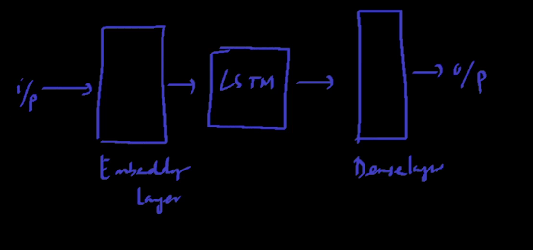

In [20]:
# Create a tensorflow sequenctial model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

In [21]:
model = Sequential()
model.add(Embedding(8,50,input_length=8))
# 8- cols in X , 50 - no. of nodes (HP)
model.add(GRU(150))
model.add(Dense(36,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [22]:
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

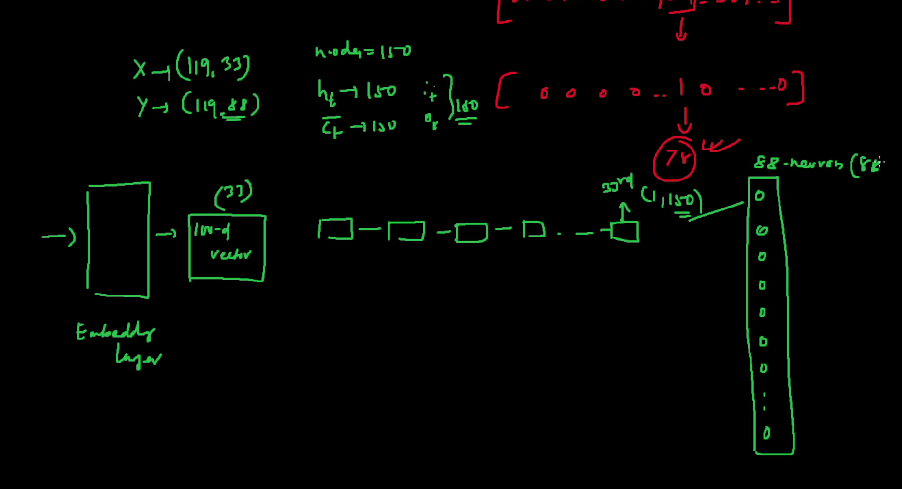

In [24]:
model.fit(X,y,epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.0000e+00 - loss: 3.5840
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0853 - loss: 3.5752
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0825 - loss: 3.5690
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1033 - loss: 3.5610
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1137 - loss: 3.5527
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1137 - loss: 3.5444
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1137 - loss: 3.5347
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1137 - loss: 3.5232
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1137 - loss: 3.5113
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1137 - loss: 3.4949
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1137 - loss: 3.4805
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1137 

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 8, 50)          │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 150)            │        90,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 36)             │         5,436 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,210 (1.11 MB)

 Trainable params: 96,736 (377.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 193,474 (755.76 KB)

In [32]:
# Test the model

text2 = "today"
# tokenisation
# apdding
# modelprediction

tokenized_text =tokenizer.texts_to_sequences([text2])[0]
padded_text = pad_sequences([tokenized_text], maxlen = 9, padding ='pre')
output=model.predict(padded_text)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [33]:
# The neuron with highest value/ probability in above would be the final output

import numpy as np
np.argmax(model.predict(padded_text))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


np.int64(18)

In [ ]:
tokenizer.word_index

{'the': 1,
 'is': 2,
 'i': 3,
 'in': 4,
 'and': 5,
 'weather': 6,
 'beautiful': 7,
 'today': 8,
 'love': 9,
 'walking': 10,
 'park': 11,
 'birds': 12,
 'are': 13,
 'singing': 14,
 'sky': 15,
 'clear': 16,
 'sometimes': 17,
 'it': 18,
 'rains': 19,
 'heavily': 20,
 'evening': 21,
 'enjoy': 22,
 'reading': 23,
 'books': 24,
 'on': 25,
 'quiet': 26,
 'rainy': 27,
 'nights': 28,
 'nature': 29,
 'always': 30,
 'brings': 31,
 'peace': 32,
 'happiness': 33,
 'to': 34,
 'mind': 35}

In [ ]:
# Prediction is 'it': 18,

**Improvements**
- Increasing LSTM units
- Increase the Dense Layers
- Increasing the data
- Using a pre-trained model on larger corpus of data.
- Hyperparameter Optimisation
